# Radio Frequency (RF) Spectrum Filters

This tutorial demonstrates how to use STK's Communications capability and RF spectrum filters to enable transmission reception using PySTK. It is inspired by [this tutorial](https://help.agi.com/stk/Content/training/DetailedInterferenceAnalysis.htm).

## Problem Statement

A situation has arisen where two customers are utilizing a satellite communication downlink facility located in the Southwestern United States. One transmission is routine, but important. The other transmission is urgent.

There are only two satellite reception parabolic antenna dishes available and they sit next to each other. Although the communications are coming from different locations, they are being routed through the same satellite to the ground facility.

Here is some information that may be helpful:

- The communication satellite is geostationary.
- The satellite is transmitting two streams of data to the same ground site.
- The urgent communication link is transmitting on a frequency of $25$ GHz.
- The routine communication link is transmitting on a frequency of $25.2$ GHz.
- Both transmissions are using a data rate of $300$ Mb/Sec.
- The close proximity of the frequencies, separated by $200$ MHz, is causing interference with the data streams.

## Launch a new STK instance

Start by launching a new STK instance. In this example, `STKEngine` is used.

In [1]:
from ansys.stk.core.stkengine import STKEngine


stk = STKEngine.start_application(no_graphics=False)

## Load the starter scenario

The STK scenario used in this tutorial is included with the STK installation as a VDF file. To open the scenario, first access the STK Root object:

In [2]:
from ansys.stk.core.stkobjects import STKObjectRoot


root: STKObjectRoot = stk.new_object_root()

Then, load the VDF from the path:

In [3]:
import pathlib


install_dir = pathlib.Path(root.execute_command("GetDirectory / STKHome")[0])
scenario_filepath = str(
    install_dir
    / "Data"
    / "Resources"
    / "stktraining"
    / "VDFs"
    / "Comm_RF_Spectrum_Filters.vdf"
)
root.load_vdf(scenario_filepath, "")

Next, get the current scenario using the root object:

In [4]:
scenario = root.current_scenario

## Acquaint Yourself With the Scenario

View the communications site.

.. image:: https://help.agi.com/stk/Content/training/images/CommGndSite.png

Position the camera so that the satellite is viewable along with the communications site in the background. Notice how the satellite is targeting the communications site.

RFBOutputContext()

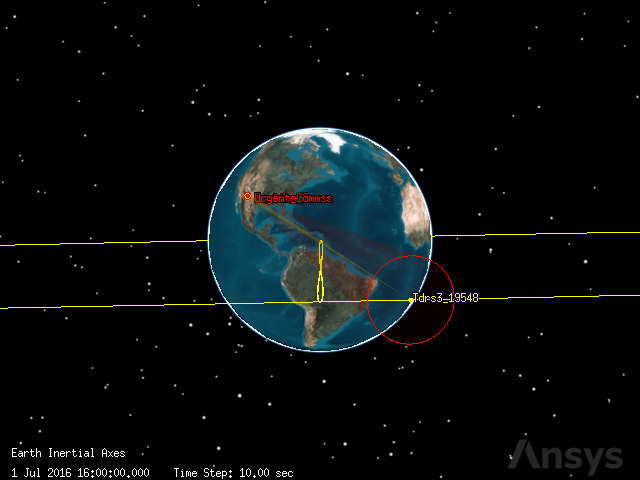

In [5]:
from ansys.stk.core.experimental.jupyterwidgets import GlobeWidget


globe_widget = GlobeWidget(root, 640, 480)
globe_widget.camera.position = [
    -5487.455182656891,
    42686.16671890387,
    11571.702360892219,
]
globe_widget.show()

## Build the Constellations

Prior to analyzing filters, you need to double check if Urgent_Comms is being interfered with by Routine_Comms. You need to set up the three constellations (Receiver, Transmitter, Interference) to calculate interference.

Begin with the receiver constellation. Create the Receiver Constellation and assign the receiver to it

In [6]:
from ansys.stk.core.stkobjects import STKObjectType


receiver_constellation = scenario.children.new(STKObjectType.CONSTELLATION, "Receiver")
urgent_receiver = root.get_object_from_path(
    "Facility/Urgent_Comms/Sensor/Tgt_Tdrs/Receiver/Urgent_Rcv"
)
receiver_constellation.objects.add_object(urgent_receiver)

Create the Transmitter Constellation and assign the routine transmitter to it

In [7]:
transmitter_constellation = scenario.children.new(
    STKObjectType.CONSTELLATION, "Transmitter"
)
tdrs_satellite = root.get_object_from_path("Satellite/Tdrs3_19548")
urgent_transmitter = root.get_object_from_path(
    "Satellite/Tdrs3_19548/Sensor/Tgt_Uc/Transmitter/Urgent_Xmt"
)
transmitter_constellation.objects.add_object(urgent_transmitter)

Create the Interference Constellation and assign the urgent transmitter to it

In [8]:
interference_constellation = scenario.children.new(
    STKObjectType.CONSTELLATION, "Interference"
)
routine_transmitter = root.get_object_from_path(
    "Satellite/Tdrs3_19548/Sensor/Tgt_Rc/Transmitter/Routine_Xmt"
)
interference_constellation.objects.add_object(routine_transmitter)

## Build the Comm System

The CommSystem object models dynamically-configured communications links between constellations of transmitters and receivers. Create a new CommSystem object:

In [9]:
comm_system = scenario.children.new(STKObjectType.COMM_SYSTEM, "CommSystem")

Add the constellations to the Comm System:

In [10]:
comm_system.transmitters.add_object(transmitter_constellation)
comm_system.receivers.add_object(receiver_constellation)
comm_system.interference_sources.add_object(interference_constellation)

The default Start and Stop times for the CommSystem interval correspond to the scenario’s time period. The default step size is one (1) second. Update the step size so the communication link will be calculated every 60 seconds:

In [11]:
comm_system.step_size = 60

## Calculate Interference

Create a custom graph that represents the carrier to noise and carrier to noise with interference on the same axis:

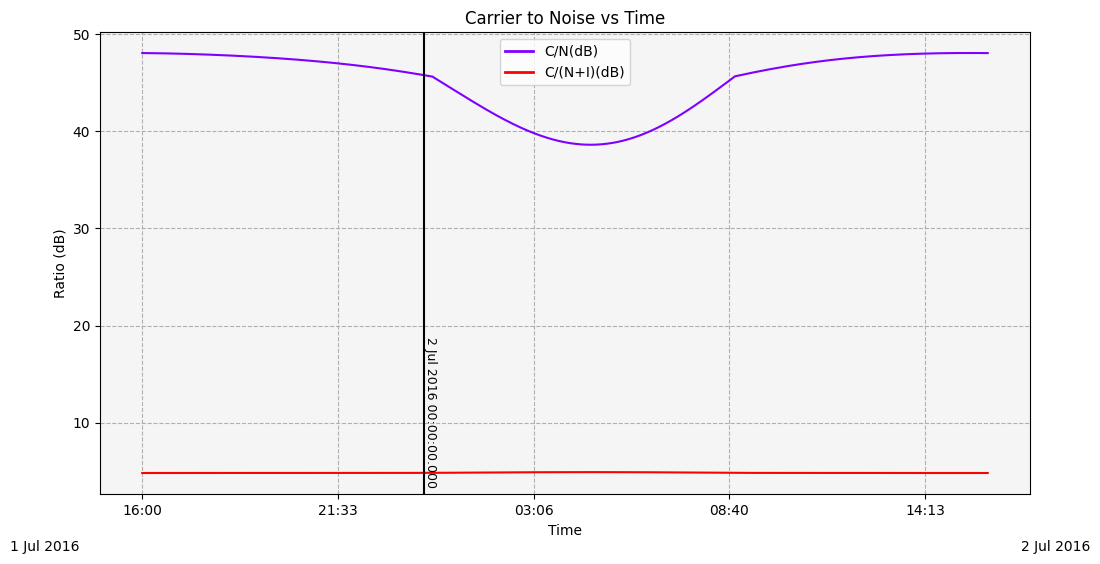

In [12]:
import matplotlib.pyplot as plt

from ansys.stk.extensions.data_analysis.graphs.graph_helpers import line_chart


start_time = scenario.start_time
stop_time = scenario.stop_time
df = (
    comm_system.data_providers.item("Link Information")
    .execute_elements(start_time, stop_time, 60, ["C/N", "Time", "C/(N+I)"])
    .data_sets.to_pandas_dataframe()
)
axes = [
    {
        "use_unit": True,
        "unit_squared": None,
        "ylog10": False,
        "y2log10": False,
        "label": "Ratio",
        "lines": [
            {
                "y_name": "c/n",
                "label": "C/N",
                "use_unit": True,
                "unit_squared": None,
                "dimension": "Ratio",
            },
            {
                "y_name": "c/(n+i)",
                "label": "C/(N+I)",
                "use_unit": True,
                "unit_squared": None,
                "dimension": "Ratio",
            },
        ],
    }
]
line_chart(
    [df],
    root,
    ["c/n", "c/(n+i)"],
    ["time"],
    axes,
    "time",
    "Time",
    "Carrier to Noise vs Time",
    colormap=None,
    time_unit_abbreviation="UTCG",
    formatter=None,
)
plt.show()

As you can see the line representing the clean carrier wave (C/N (dB)) and the line representing the wave that is receiving interference (C/N + I (dB)) are different. There is interference against the carrier wave.

## Set Correct Units

Before generating any data tables, the units for the "Ratio" dimension need to be set correctly. The UI defaults to a linear scale while the STK Object Model defaults to a logarithmic scale. Setting the units of "Ratio" below will make units consistent across platforms.

If you would like to use a logarithmic scale, simply change "units" to "dB" in `set_current_unit()`.

In [13]:
root.units_preferences.item("Ratio").set_current_unit("units")

## Calculate Link Budget

Determine how good the quality of the communication is by calculating a link budget report and looking at the Bit Error Rate (BER):

In [14]:
provider = comm_system.data_providers.item("Link Information")
provider.pre_data = "Facility/Urgent_Comms/Sensor/Tgt_Tdrs/Receiver/Urgent_Rcv"

link_budget_report = provider.execute(
    scenario.start_time, scenario.stop_time, 60
).data_sets.to_pandas_dataframe()

# Focus on the BER and BER+I columns
link_budget_report[["ber", "ber+i"]]

,ber,ber+i
0,1e-30,0.006917962780142994
1,1e-30,0.006917970086206964
2,1e-30,0.006917960245440189
3,1e-30,0.0069179498555238
4,1e-30,0.006917939149355964
...,...,...
1436,1e-30,0.006917931413933708
1437,1e-30,0.006917921791256923
1438,1e-30,0.006917911786431534
1439,1e-30,0.006917901533917336


The BER column shows the link performance without interference while the BER + I shows the link performance with interference. The difference between the BER values with and without interference shows that interference has a major impact on the communications.

## Bandwidth Analysis

The transmitted spectrum is modeled as a flat spectrum with unity magnitude across the transmitter’s bandwidth. The receiver’s frequency response is also modeled as a flat response across the receiver’s bandwidth. Therefore, the bandwidth ratio is computed as just a simple ratio of the receiver’s bandwidth to the transmitter’s bandwidth.

If the transmitter’s bandwidth is totally contained within the receiver’s bandwidth, the ratio will be one (1.0). For a receiver that has an auto scaled bandwidth and an auto tracked frequency, this value will be one (1). Otherwise, the value may be less than one (1.0) if the receiver center frequency and the transmitter frequency are not the same or the receiver’s bandwidth is totally contained within the transmitter’s bandwidth.

View the Bandwidth (MHz) and Bandwidth Overlap (units) columns on the link budget report. Note that the Bandwidth Overlap is one (1.0). This shows that all of the energy from the transmitted signal is being captured at the receiver. The bandwidth is 300 MHz, which is what it should be.

In [15]:
link_budget_report[["bandwidth", "bandwidth overlap"]]

,bandwidth,bandwidth overlap
0,300.0,1.0
1,300.0,1.0
2,300.0,1.0
3,300.0,1.0
4,300.0,1.0
...,...,...
1436,300.0,1.0
1437,300.0,1.0
1438,300.0,1.0
1439,300.0,1.0


Before using filters, experiment and change the receiver’s bandwidth to determine the effect that change might have on signal quality. The smaller the bandwidth, the less information that can be sent or received. The Bandwidth Auto Scale option allows the receiver to adjust its bandwidth to that of the current transmitter. To manually configure the receiver's bandwidth, disable the bandwidth autoscale option.

In [16]:
from ansys.stk.core.stkobjects import ReceiverModelComplex


urgent_receiver_model = ReceiverModelComplex(
    urgent_receiver.model_component_linking.component
)
urgent_receiver_model.scale_bandwidth_automatically = False

Now, set the bandwidth to 150 MHz:

In [17]:
urgent_receiver_model.bandwidth = 150

Refresh the link budget report to see how this change affected the Bandwidth Overlap:

In [18]:
comm_system.clear()

link_budget_report = (
    comm_system.data_providers.get_item_by_name("Link Information")
    .execute(scenario.start_time, scenario.stop_time, 60)
    .data_sets.to_pandas_dataframe()
)
link_budget_report[["bandwidth", "bandwidth overlap"]]

,bandwidth,bandwidth overlap
0,150.0,0.5
1,150.0,0.5
2,150.0,0.5
3,150.0,0.5
4,150.0,0.5
...,...,...
1436,150.0,0.5
1437,150.0,0.5
1438,150.0,0.5
1439,150.0,0.5


## Signal PSD

The Power Spectral Density (PSD), which describes how the power of a signal or time series is distributed with frequency. Here power can be the actual physical power, or more often, for convenience with abstract signals, can be defined as the squared value of the signal. This assumes the actual power of a signal is a 1-ohm voltage load.

The units of power spectral density are commonly expressed in watts per hertz (W/Hz). A spectral filter allows only a specific bandwidth of the electromagnetic spectrum to pass.

Up until now, the power has been spread equally across frequency bands. In reality, the power is concentrated around the band center. Power Spectral Density allows you to model the reality case. The PSD option allows the scenario to model the actual spectral shape of the transmitted signal based on the modulation, data rate, etc. When using Signal PSD is enabled, the modulation’s power spectral density is used to determine the Bandwidth Overlap Factor. If this option is not selected, the PSD will be modeled as a flat spectrum with unity magnitude across the transmitter’s bandwidth.

Filters can be applied to enhance the magnitude over certain frequencies content while suppressing the magnitudes over other frequencies. The use of Spectral Filters on transmitters modifies the spectral shape. The use of Spectral Filters on receivers helps reduce the impact of out of band signals from jammers and other sources. Enable Signal PSD to be used for both transmitters:

In [19]:
root.units_preferences.item("Ratio").set_current_unit(
    "dB"
)  # Change "Ratio" units back to a logarithmic scale to match tutorial graphs for the remainder of the tutorial.

from ansys.stk.core.stkobjects import TransmitterModelComplex


routine_transmitter_model = TransmitterModelComplex(
    routine_transmitter.model_component_linking.component
)
routine_transmitter_model.modulator.enable_signal_psd = True

urgent_transmitter_model = TransmitterModelComplex(
    urgent_transmitter.model_component_linking.component
)
urgent_transmitter_model.modulator.enable_signal_psd = True

Refresh the Carrier to Noise vs Time graph and examine how the interference has changd:

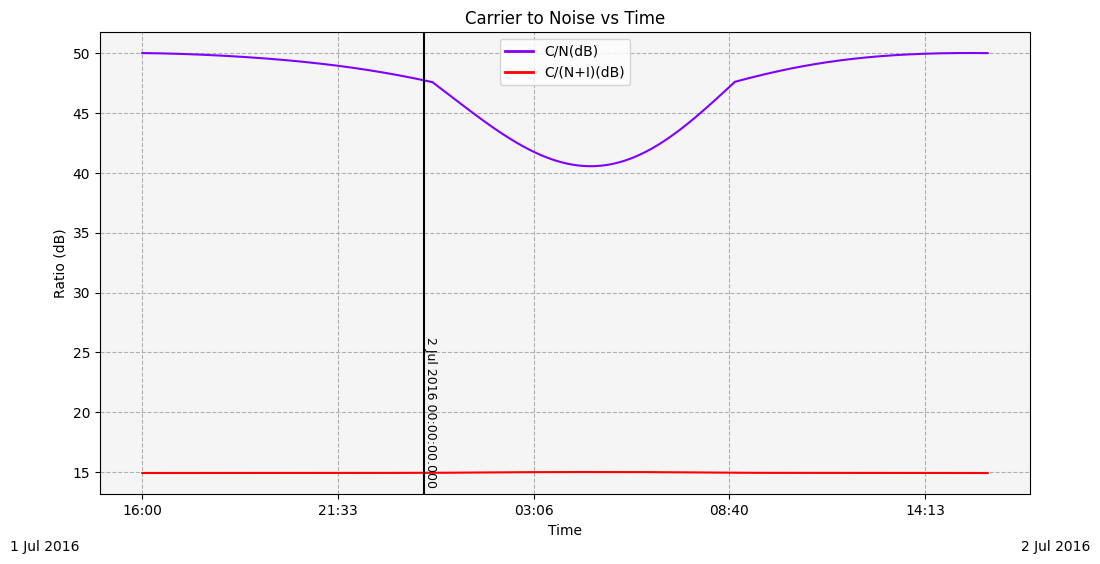

In [20]:
comm_system.clear()

df2 = (
    comm_system.data_providers.item("Link Information")
    .execute_elements(start_time, stop_time, 60, ["C/N", "Time", "C/(N+I)"])
    .data_sets.to_pandas_dataframe()
)
axes2 = [
    {
        "use_unit": True,
        "unit_squared": None,
        "ylog10": False,
        "y2log10": False,
        "label": "Ratio",
        "lines": [
            {
                "y_name": "c/n",
                "label": "C/N",
                "use_unit": True,
                "unit_squared": None,
                "dimension": "Ratio",
            },
            {
                "y_name": "c/(n+i)",
                "label": "C/(N+I)",
                "use_unit": True,
                "unit_squared": None,
                "dimension": "Ratio",
            },
        ],
    }
]
line_chart(
    [df2],
    root,
    ["c/n", "c/(n+i)"],
    ["time"],
    axes2,
    "time",
    "Time",
    "Carrier to Noise vs Time",
    colormap=None,
    time_unit_abbreviation="UTCG",
    formatter=None,
)

plt.show()

Refresh the Link Budget Report and see the changes in bandwidth overlap:

In [21]:
comm_system.clear()

link_budget_report = (
    comm_system.data_providers.get_item_by_name("Link Information")
    .execute(scenario.start_time, scenario.stop_time, 60)
    .data_sets.to_pandas_dataframe()
)
link_budget_report[["bandwidth", "bandwidth overlap"]]

,bandwidth,bandwidth overlap
0,150.0,-1.0833579655867
1,150.0,-1.0833579655867
2,150.0,-1.0833579655867
3,150.0,-1.0833579655867
4,150.0,-1.0833579655867
...,...,...
1436,150.0,-1.0833579655867
1437,150.0,-1.0833579655867
1438,150.0,-1.0833579655867
1439,150.0,-1.0833579655867


## Changing the Modulation Type

One way to minimize bandwidth costs is to change the modulation to Phase Shift Keying with 16 Constellation Points (16PSK). Change the modulation to 16PSK and see if this has an effect on your signal quality:

In [22]:
urgent_transmitter_model.set_modulator("16PSK")
urgent_transmitter_model.modulator.enable_signal_psd = True

Refresh the Link Budget Report and see the changes in bandwidth overlap:

In [23]:
comm_system.clear()

link_budget_report = (
    comm_system.data_providers.get_item_by_name("Link Information")
    .execute(scenario.start_time, scenario.stop_time, 60)
    .data_sets.to_pandas_dataframe()
)
link_budget_report[["bandwidth", "bandwidth overlap"]]

,bandwidth,bandwidth overlap
0,150.0,-0.4145438790212007
1,150.0,-0.4145438790212007
2,150.0,-0.4145438790212007
3,150.0,-0.4145438790212007
4,150.0,-0.4145438790212007
...,...,...
1436,150.0,-0.4145438790212007
1437,150.0,-0.4145438790212007
1438,150.0,-0.4145438790212007
1439,150.0,-0.4145438790212007


Revert back to the previous modulator and reset the receiver bandwidth to use auto scaling:

In [24]:
urgent_transmitter_model.set_modulator("QPSK")
urgent_transmitter_model.modulator.enable_signal_psd = True

urgent_receiver_model.scale_bandwidth_automatically = True

## Spectrum and Filter Graphs

Run a spectrum and filter graph to determine the cutoff frequency of the interference transmitter (Noise_Xmt):

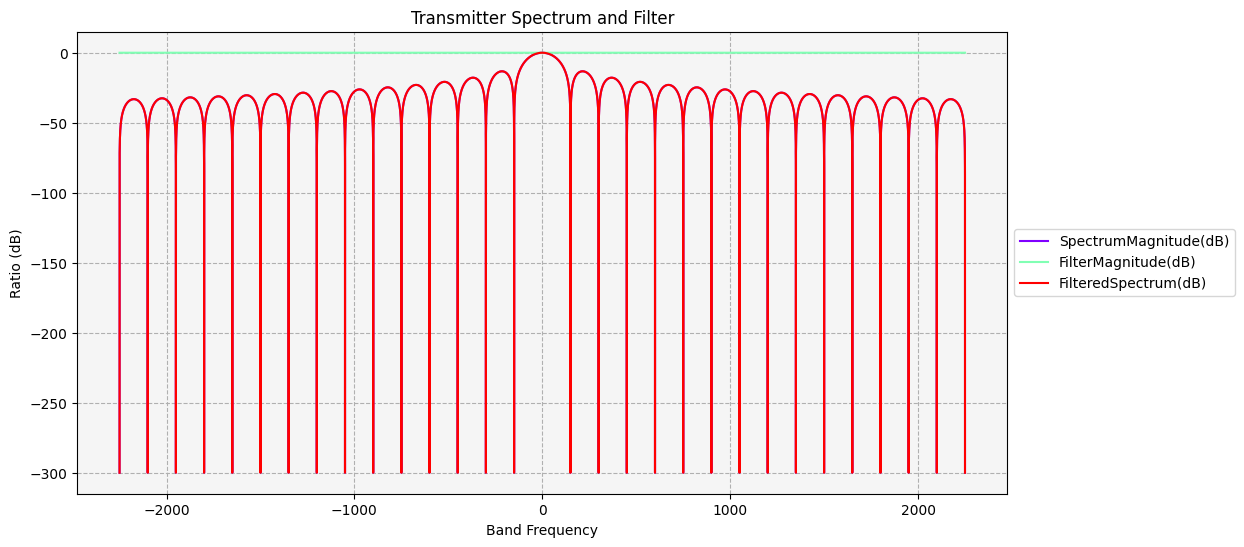

In [25]:
from ansys.stk.extensions.data_analysis.graphs.transmitter_graphs import (
    transmitter_spectrum_and_filter_line_chart,
)


transmitter_spectrum_and_filter_line_chart(urgent_transmitter)

# Format legend so it does not overlap with the graph
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

The graph shows that the bandwidth encompasses 4500 MHz. The main beam is 300 MHz.

## Butterworth Filter

The filter cutoff frequency controls where the signal will start being suppressed and the filter order (rolloff) controls how steep the filter magnitude is to drop or how fast the signal is to get suppressed.

The Butterworth filter is less complex and maintains a flat profile over the filter bandwidth, but doesn’t have as steep a rolloff as Chebyshev. However, the Chebyshev is more complex and uses recursive equations (not a closed formula) and there is a ripple in the passband. This means there is not a flat profile over the filter bandwidth. The Butterworth filter has a frequency response with flat pass and stop bands. Regenerate a Butterworth Filter:

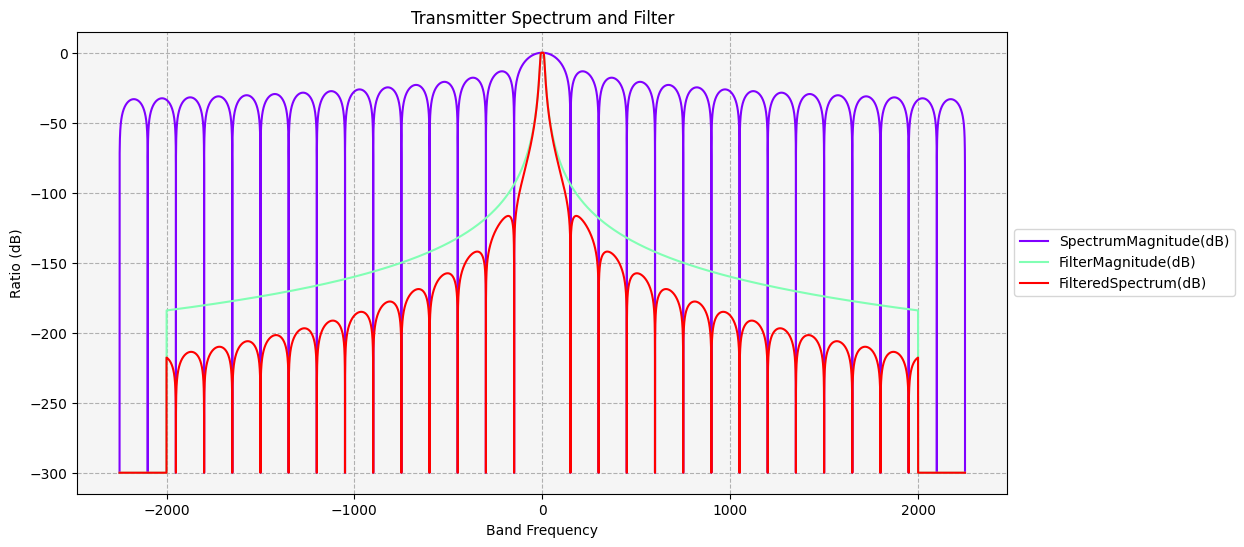

In [26]:
urgent_transmitter_model.enable_filter = True
urgent_transmitter_model.filter_component_linking.component.lower_bandwidth_limit = (
    -2000
)
urgent_transmitter_model.filter_component_linking.component.upper_bandwidth_limit = 2000
transmitter_spectrum_and_filter_line_chart(urgent_transmitter)

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

This has removed 500 MHz of bandwidth. Using the default frequency cutoff, the cutoff has been narrowed to ten (10) MHz on both sides of the carrier wave. See on the graph that the bandwidth has been suppressed on both sides of the carrier wave.

Refresh the Link Budget Report to see how this affects the BER:

In [27]:
comm_system.clear()
link_budget_report = (
    comm_system.data_providers.get_item_by_name("Link Information")
    .execute(scenario.start_time, scenario.stop_time, 60)
    .data_sets.to_pandas_dataframe()
)
link_budget_report[["ber", "ber+i"]]

,ber,ber+i
0,1e-30,0.027371745971626938
1,1e-30,0.027371765735932287
2,1e-30,0.02737174179772181
3,1e-30,0.027371716500498147
4,1e-30,0.027371690437327338
...,...,...
1436,1e-30,0.027371671312116763
1437,1e-30,0.027371647892651004
1438,1e-30,0.027371623539385322
1439,1e-30,0.027371598594259323


Although the filter is working, the BER to dropped below acceptable levels during periods of the analysis. The BER with interference has increased as well. This indicates that the communication link is still poor.

To ensure the filter has a steeper roll off at the cutoff frequency, increase the filter order and refresh the Transmitter Spectrum and Filter graph:

## Change the Filter Order

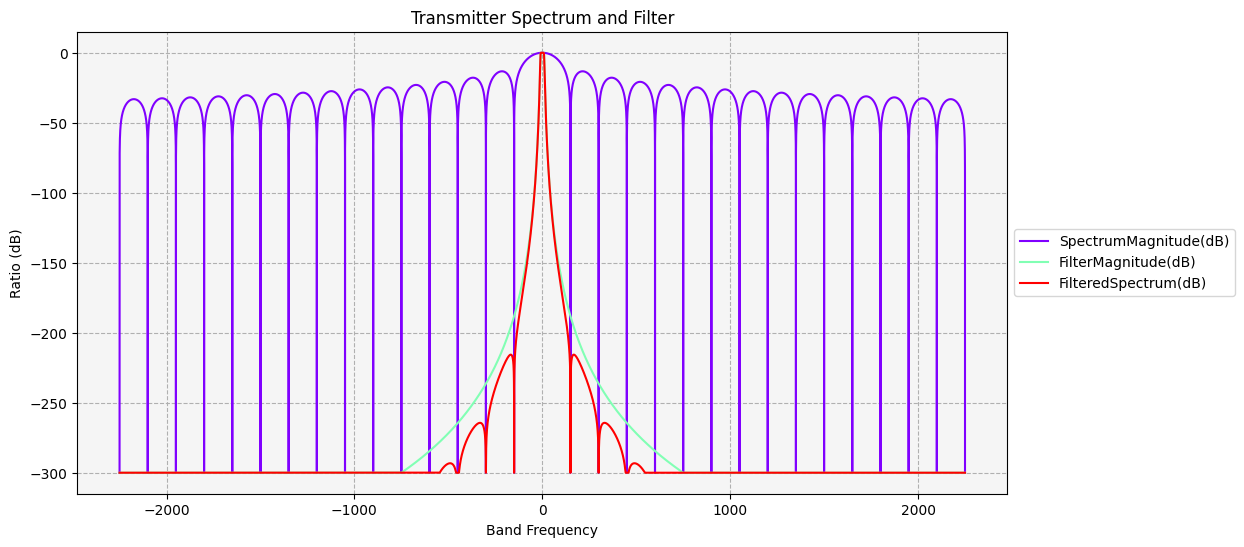

In [28]:
urgent_transmitter_model.filter_component_linking.component.order = 8
transmitter_spectrum_and_filter_line_chart(urgent_transmitter)

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

There was a steep roll off in the filter profile. The steeper the roll off the better, but there are tradeoffs. One tradeoff is the steeper the roll off, the more complex the filter function. The more complex the filter function, the harder it is to implement, due to the complexity.

Refresh the Link Budget Report to see how this affects the BER+I:

In [29]:
comm_system.clear()
link_budget_report = (
    comm_system.data_providers.get_item_by_name("Link Information")
    .execute(scenario.start_time, scenario.stop_time, 60)
    .data_sets.to_pandas_dataframe()
)
link_budget_report[["ber", "ber+i"]]

,ber,ber+i
0,1e-30,0.028505281154327988
1,1e-30,0.02850530140993462
2,1e-30,0.028505276876667835
3,1e-30,0.02850525095060517
4,1e-30,0.028505224239555028
...,...,...
1436,1e-30,0.028505204638928965
1437,1e-30,0.028505180637300627
1438,1e-30,0.028505155678659484
1439,1e-30,0.028505130113445295


The change is minimal but the BER+I is still too high.

The center beam is 300 MHz wide but the frequency cutoff is only ten (10) MHz. Widen the cutoff to -100 MHz to 100 MHz (200 MHz) and refresh the Transmitter Spectrum and Filter graph:

## Change the Cutoff Frequency

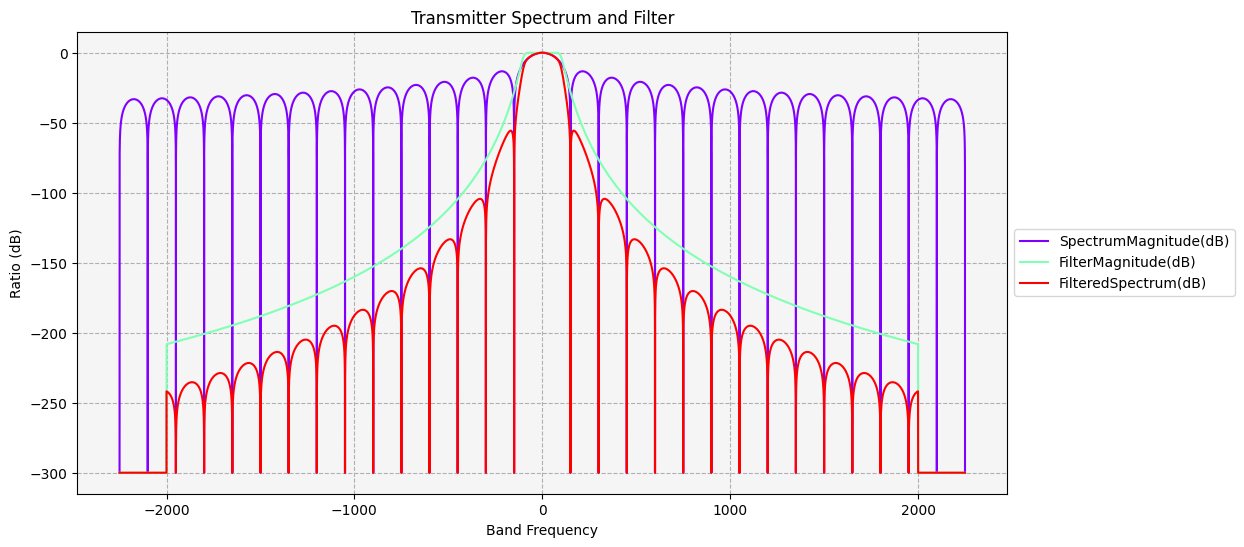

In [30]:
urgent_transmitter_model.filter_component_linking.component.cut_off_frequency = 100
transmitter_spectrum_and_filter_line_chart(urgent_transmitter)

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

Notice how the filter is now allowing more bandwidth through.

Refresh the Link Budget Report to see how this affects the BER+I:

In [31]:
comm_system.clear()
link_budget_report = (
    comm_system.data_providers.get_item_by_name("Link Information")
    .execute(scenario.start_time, scenario.stop_time, 60)
    .data_sets.to_pandas_dataframe()
)
link_budget_report[["ber", "ber+i"]]

,ber,ber+i
0,1e-30,6.556988136920271e-07
1,1e-30,6.557014177509208e-07
2,1e-30,6.556982637575129e-07
3,1e-30,6.556949307198647e-07
4,1e-30,6.556914967791454e-07
...,...,...
1436,1e-30,6.556889769553584e-07
1437,1e-30,6.556858913567802e-07
1438,1e-30,6.556826827391874e-07
1439,1e-30,6.556793961553791e-07


## Chebyshev Filter

The Chebyshev filter has a frequency response with equal ripple in the pass band. Regenerate the graph with a Chebyshev Filter:

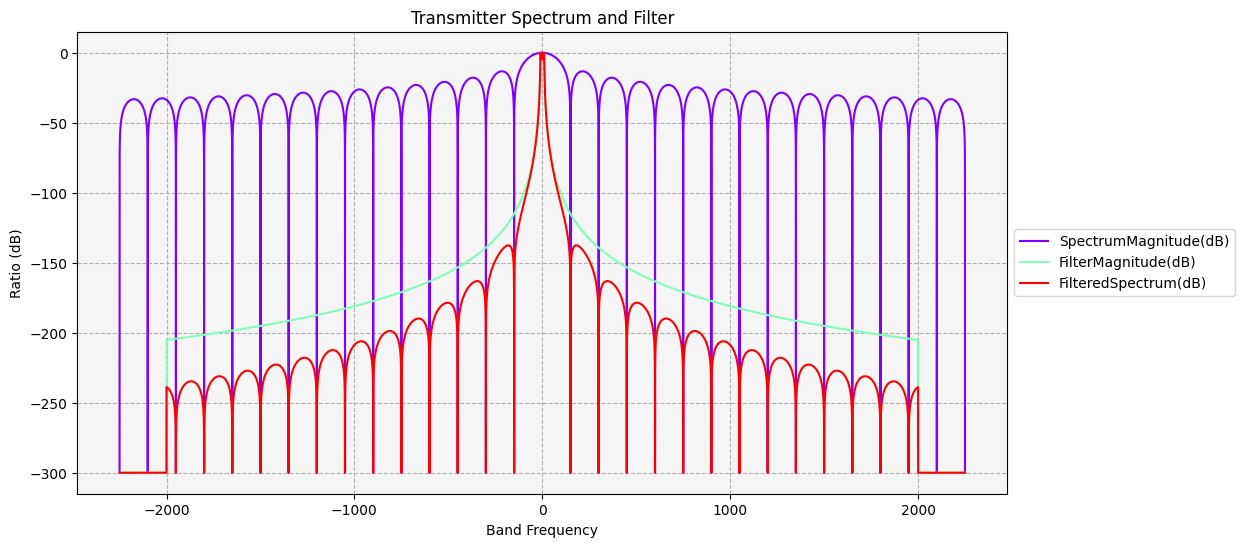

In [32]:
urgent_transmitter_model.filter_component_linking.set_component("Chebyshev")
urgent_transmitter_model.filter_component_linking.component.lower_bandwidth_limit = (
    -2000
)
urgent_transmitter_model.filter_component_linking.component.upper_bandwidth_limit = 2000
transmitter_spectrum_and_filter_line_chart(urgent_transmitter)

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

Refresh the Link Budget Report to see how this affects the BER+I:

In [33]:
comm_system.clear()
link_budget_report = (
    comm_system.data_providers.get_item_by_name("Link Information")
    .execute(scenario.start_time, scenario.stop_time, 60)
    .data_sets.to_pandas_dataframe()
)
link_budget_report[["ber", "ber+i"]]

,ber,ber+i
0,1e-30,0.07070311366881327
1,1e-30,0.07070314614086998
2,1e-30,0.07070310681123332
3,1e-30,0.07070306524877318
4,1e-30,0.0707030224278743
...,...,...
1436,1e-30,0.07070299100579819
1437,1e-30,0.07070295252839504
1438,1e-30,0.0707029125167778
1439,1e-30,0.07070287153274046


Notice the five (5) dB ripple in the filter and filtered spectrum.

## Graph the Receiver Filter

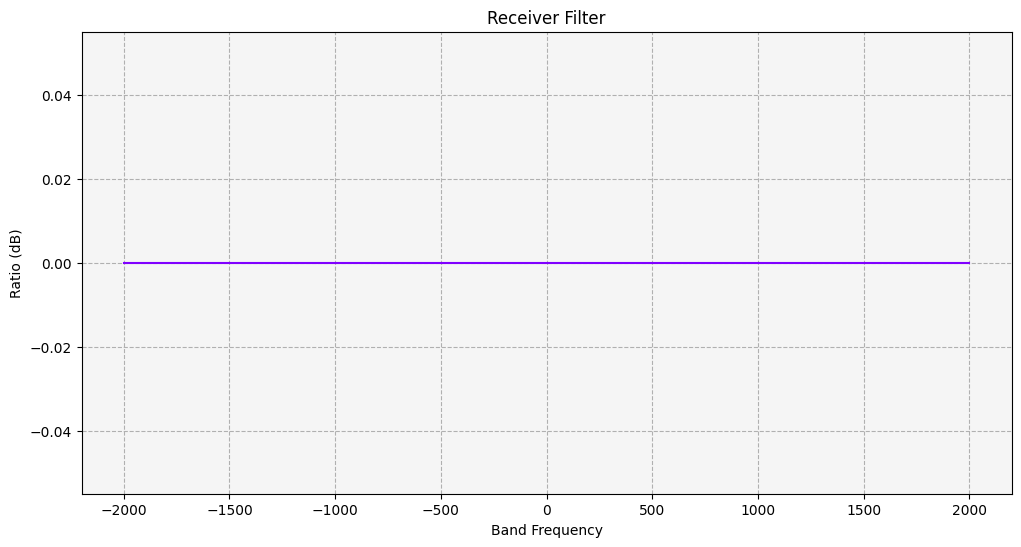

In [34]:
from ansys.stk.extensions.data_analysis.graphs.receiver_graphs import (
    receiver_filter_line_chart,
)


receiver_filter_line_chart(urgent_receiver)
plt.show()

Currently, no filter is being used, so there is no effect against the receiver.

Add the Chebyshev filter on the receiver to see what effect the filter might have on the communication link:

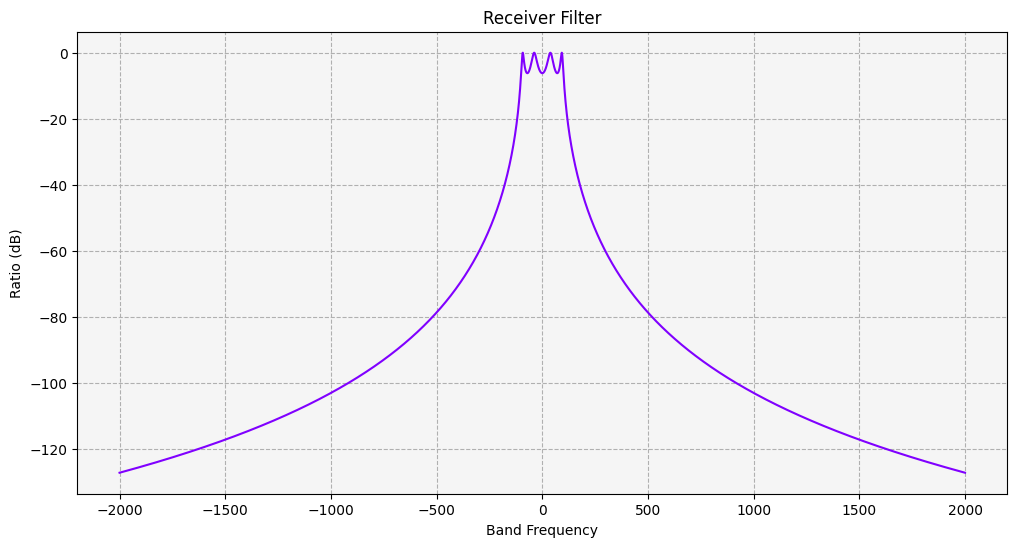

In [35]:
urgent_receiver_model.enable_filter = True
urgent_receiver_model.filter_component_linking.set_component("Chebyshev")
urgent_receiver_model.filter_component_linking.component.lower_bandwidth_limit = -2000
urgent_receiver_model.filter_component_linking.component.upper_bandwidth_limit = 2000
urgent_receiver_model.filter_component_linking.component.cut_off_frequency = 100
urgent_receiver_model.filter_component_linking.component.ripple = 5
receiver_filter_line_chart(urgent_receiver)
plt.show()

Notice the five (5) dB ripple in the filter and filtered spectrum and how the filter is suppressing noise on both sides of the carrier wave.

## Change the Receiver Filter to a Butterworth:

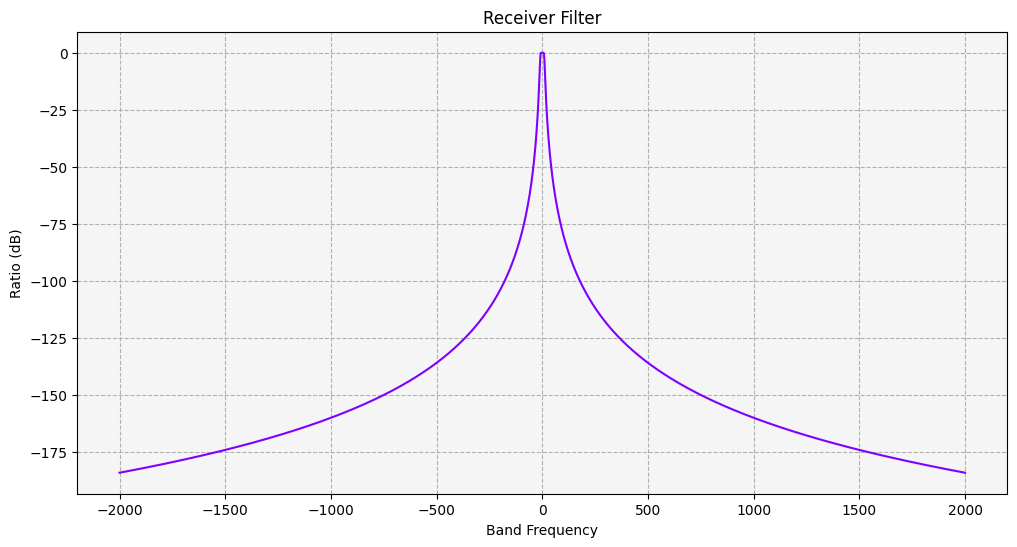

In [36]:
urgent_receiver_model.filter_component_linking.set_component("Butterworth")
urgent_receiver_model.filter_component_linking.component.lower_bandwidth_limit = -2000
urgent_receiver_model.filter_component_linking.component.upper_bandwidth_limit = 2000
urgent_receiver_model.filter_component_linking.component.cut_off_frequency = 10
receiver_filter_line_chart(urgent_receiver)
plt.show()

The ripple disappeared and the frequency cutoff isn’t so steep.

Apply the Butterworth filter to Urgent_Xmt.

In [37]:
urgent_transmitter_model.filter_component_linking.set_component("Butterworth")
urgent_transmitter_model.filter_component_linking.component.cut_off_frequency = 100
urgent_transmitter_model.filter_component_linking.component.lower_bandwidth_limit = (
    -2000
)
urgent_transmitter_model.filter_component_linking.component.upper_bandwidth_limit = 2000

Refresh the Link Budget Report to see how this affects the BER+I and Bandwidth Overlap:

In [38]:
comm_system.clear()
link_budget_report = (
    comm_system.data_providers.get_item_by_name("Link Information")
    .execute(scenario.start_time, scenario.stop_time, 60)
    .data_sets.to_pandas_dataframe()
)
link_budget_report[["ber", "ber+i", "bandwidth", "bandwidth overlap"]]

,ber,ber+i,bandwidth,bandwidth overlap
0,1e-30,1e-30,4000.0,-7.963570199208902
1,1e-30,1e-30,4000.0,-7.963570199208902
2,1e-30,1e-30,4000.0,-7.963570199208902
3,1e-30,1e-30,4000.0,-7.963570199208902
4,1e-30,1e-30,4000.0,-7.963570199208902
...,...,...,...,...
1436,1e-30,1e-30,4000.0,-7.963570199208902
1437,1e-30,1e-30,4000.0,-7.963570199208902
1438,1e-30,1e-30,4000.0,-7.963570199208902
1439,1e-30,1e-30,4000.0,-7.963570199208902


Filtering both the transmitter and the receiver minimizes interference on the communication link. The Chebyshev filter removes the greatest amount of interference, but it increases the BER values.

The Butterworth filter decreases the BER values, but there’s a bit more interference in the communication link. Both filters require the bandwidth and the amount of information that can be transmitted over the communication link to be decreased.